In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import kagglehub
import tensorflow as tf
import pickle as pkl
import os

In [4]:
path = kagglehub.dataset_download("shrutimechlearn/churn-modelling")
print("Path to dataset files:", path)

100%|██████████| 262k/262k [00:01<00:00, 240kB/s]

Extracting files...
Path to dataset files: C:\Users\aksha\.cache\kagglehub\datasets\shrutimechlearn\churn-modelling\versions\1


In [5]:
df=pd.read_csv(os.path.join(path,"Churn_Modelling.csv"))
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
x=df.iloc[:,3:13]
y=df.iloc[:,13]

In [7]:
x.columns


Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'],
      dtype='str')

In [8]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
x['Gender']=le.fit_transform(x['Gender'])

In [10]:
with open("gender_encoder.pkl",'wb') as file:
    pkl.dump(le,file)

In [11]:
geo_onehot=OneHotEncoder(drop='first',handle_unknown='ignore')
Geography=pd.DataFrame(geo_onehot.fit_transform(x[['Geography']]).toarray(),columns=geo_onehot.get_feature_names_out(['Geography']))

Geography

,Geography_Germany,Geography_Spain
0,0.0,0.0
1,0.0,1.0
2,0.0,0.0
3,0.0,0.0
4,0.0,1.0
...,...,...
9995,0.0,0.0
9996,0.0,0.0
9997,0.0,0.0
9998,1.0,0.0


In [12]:
with open("Onehot.pkl",'wb')as file:
  pkl.dump(geo_onehot,file)

In [13]:
x=pd.concat([x.drop(columns='Geography'),Geography],axis=1)
x

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1.0,0.0


In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [16]:
with open("scaler_file.pkl","wb") as file:
  pkl.dump(sc,file)

In [17]:
x_train.shape

(8000, 11)

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU

In [19]:
classifier=Sequential()
#input layer
classifier.add(Dense(units=11,activation='relu'))
#first hidden layer
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.3))
#first hidden layer
classifier.add(Dense(units=6,activation='relu'))
classifier.add(Dropout(0.2))
#output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [20]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [21]:
classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

BY defualt learning rate of adam is 0.01 if you wanna change it then

In [22]:
import tensorflow
opt=tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [23]:
import tensorflow as tf
early_stopping=keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0,
)


In [24]:
model_history=classifier.fit(x_train,y_train,validation_split=0.33,epochs=100,callbacks=early_stopping)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7330 - loss: 0.5888 - val_accuracy: 0.7910 - val_loss: 0.5074
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7951 - loss: 0.5091 - val_accuracy: 0.7910 - val_loss: 0.4752
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7957 - loss: 0.4909 - val_accuracy: 0.7910 - val_loss: 0.4611
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7959 - loss: 0.4787 - val_accuracy: 0.7910 - val_loss: 0.4505
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7977 - loss: 0.4650 - val_accuracy: 0.7910 - val_loss: 0.4433
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8011 - loss: 0.4581 - val_accuracy: 0.7906 - val_loss: 0.4373
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8063 - loss: 0.4508 - val_accuracy: 0.7974 - val_loss: 0.4275
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8091 - loss: 0.4374 - val_accu

In [ ]:
#hyper parameter tuning


In [25]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,accuracy_score
y_pred=classifier.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [26]:
y_pred

array([[0.01342744],
       [0.01338008],
       [0.11249092],
       ...,
       [0.60673124],
       [0.07793744],
       [0.2785481 ]], shape=(2000, 1), dtype=float32)

In [27]:
y_pred=(y_pred>0.5).astype(int)

In [28]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]], shape=(2000, 1))

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.76      0.41      0.53       393

    accuracy                           0.86      2000
   macro avg       0.81      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000



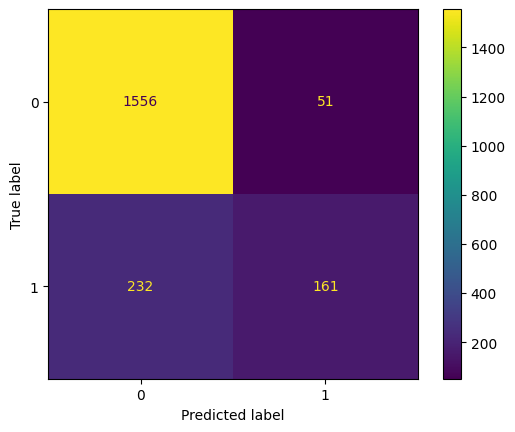

In [30]:
cm_display=ConfusionMatrixDisplay.from_predictions(y_test,y_pred)


In [31]:
accuracy_score(y_test,y_pred)

0.8585

In [32]:
classifier.save('churn_model.h5')

55

58
